# Retail Inventory Optimization

In [166]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Exploration & Analysis

In [167]:
# Load cleaned SQL datset: sales_data_final.csv
df = pd.read_csv("sales_data_final.csv")
print("First 5 rows:\n", df.head())

First 5 rows:
        Date Store ID Product ID     Category Region  Inventory Level  \
0  1/1/2022     S001      P0001  Electronics  North              195   
1  1/1/2022     S001      P0002     Clothing  North              117   
2  1/1/2022     S001      P0003     Clothing  North              247   
3  1/1/2022     S001      P0004  Electronics  North              139   
4  1/1/2022     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount  ... Promotion  \
0         102            252  72.72         5  ...         0   
1         117            249  80.16        15  ...         1   
2         114            612  62.94        10  ...         1   
3          45            102  87.63        10  ...         0   
4          65            271  54.41         0  ...         0   

   Competitor Pricing  Seasonality Epidemic  Demand  Overstock  Stockout  \
0               85.73       Winter        0     115          0         0   
1              

In [168]:
# Clean column names and remove extra spaces
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [169]:
print("First 5 rows:\n", df.head())

First 5 rows:
        Date Store_ID Product_ID     Category Region  Inventory_Level  \
0  1/1/2022     S001      P0001  Electronics  North              195   
1  1/1/2022     S001      P0002     Clothing  North              117   
2  1/1/2022     S001      P0003     Clothing  North              247   
3  1/1/2022     S001      P0004  Electronics  North              139   
4  1/1/2022     S001      P0005    Groceries  North              152   

   Units_Sold  Units_Ordered  Price  Discount  ... Promotion  \
0         102            252  72.72         5  ...         0   
1         117            249  80.16        15  ...         1   
2         114            612  62.94        10  ...         1   
3          45            102  87.63        10  ...         0   
4          65            271  54.41         0  ...         0   

   Competitor_Pricing  Seasonality Epidemic  Demand  Overstock  Stockout  \
0               85.73       Winter        0     115          0         0   
1              

In [170]:
# Checking column names, datatypes, missing values, and if SQL columns imported properly
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store_ID            76000 non-null  object 
 2   Product_ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory_Level     76000 non-null  int64  
 6   Units_Sold          76000 non-null  int64  
 7   Units_Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather_Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor_Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
 16  Over

In [171]:
print(df.columns)

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Region',
       'Inventory_Level', 'Units_Sold', 'Units_Ordered', 'Price', 'Discount',
       'Weather_Condition', 'Promotion', 'Competitor_Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Overstock', 'Stockout', 'Reorder_Needed',
       'Month_Num', 'Day_Of_Week'],
      dtype='object')


In [172]:
# Convert date column into datetime format
df["Date"] = pd.to_datetime(df["Date"])

In [173]:
# Sort the data chronologically by date, store, and product
df = df.sort_values(["Date", "Store_ID", "Product_ID"]).reset_index(drop=True)

In [174]:
# Check for missing values
print(df.isnull().sum())

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Weather_Condition     0
Promotion             0
Competitor_Pricing    0
Seasonality           0
Epidemic              0
Demand                0
Overstock             0
Stockout              0
Reorder_Needed        0
Month_Num             0
Day_Of_Week           0
dtype: int64


In [175]:
# Dataset summary
print(df.describe())

                      Date  Inventory_Level    Units_Sold  Units_Ordered  \
count                76000     76000.000000  76000.000000   76000.000000   
mean   2023-01-15 12:00:00       301.062842     88.827316      89.090645   
min    2022-01-01 00:00:00         0.000000      0.000000       0.000000   
25%    2022-07-09 18:00:00       136.000000     58.000000       0.000000   
50%    2023-01-15 12:00:00       227.000000     84.000000       0.000000   
75%    2023-07-24 06:00:00       408.000000    114.000000     121.000000   
max    2024-01-30 00:00:00      2267.000000    426.000000    1616.000000   
std                    NaN       226.510161     43.994525     162.404627   

              Price      Discount     Promotion  Competitor_Pricing  \
count  76000.000000  76000.000000  76000.000000        76000.000000   
mean      67.726028      9.087039      0.328947           69.454029   
min        4.740000      0.000000      0.000000            4.290000   
25%       31.997500      5.0000

In [176]:
# Check date range of the dataset
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

Earliest Date: 2022-01-01 00:00:00
Latest Date: 2024-01-30 00:00:00


Exploratory Data Analysis (EDA)

In [177]:
# Daily Demand Trend
# Checking if demand increased over time? Are there seasonal spikes? Did epidemic period affect sales?
daily_demand = df.groupby("Date")["Demand"].sum()
print(daily_demand.head())

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
Name: Demand, dtype: int64


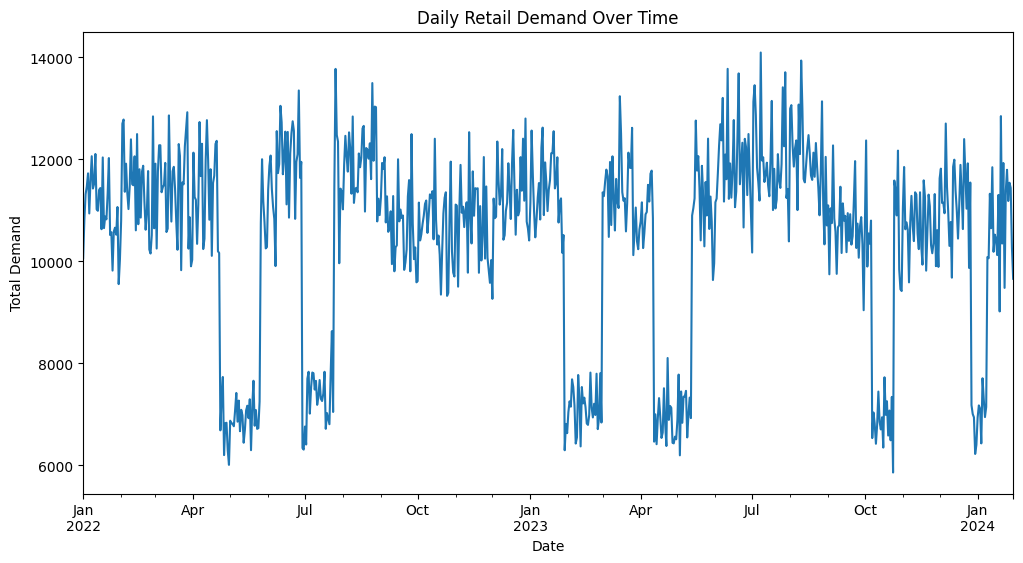

In [178]:
# Graph Daily Demand Trend
import matplotlib.pyplot as plt

daily_demand.plot(figsize=(12,6))

plt.title("Daily Retail Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.show()

In [179]:
# Demand by category
category_demand = df.groupby("Category")["Demand"].mean().sort_values(ascending=False)

print(category_demand)

Category
Groceries      120.976447
Clothing       112.619737
Electronics     97.482018
Toys            92.606955
Furniture       73.581140
Name: Demand, dtype: float64


In [180]:
# Stockout Analysis
# Stockout rate by category
stockout_rate = (
    df.groupby("Category")["Stockout"]
    .mean()
    .reset_index()
    .sort_values(by="Stockout", ascending=False)
)

print(stockout_rate)

      Category  Stockout
0     Clothing  0.143257
4         Toys  0.109586
1  Electronics  0.105811
3    Groceries  0.104375
2    Furniture  0.058626


In [181]:
# Overstock Analysis
# Overstock rate by category
overstock_rate = (
    df.groupby("Category")["Overstock"]
    .mean()
    .reset_index()
    .sort_values(by="Overstock", ascending=False)
)

print(overstock_rate)

      Category  Overstock
2    Furniture   0.208333
1  Electronics   0.166996
3    Groceries   0.159178
0     Clothing   0.133470
4         Toys   0.114004


In [182]:
# Promotion Performance
promo_performance = (
    df.groupby("Promotion")[["Demand", "Units_Sold"]]
    .mean()
)

print(promo_performance)

               Demand  Units_Sold
Promotion                        
0           95.026843   81.833314
1          123.269400  103.095080


In [183]:
# Regional Analysis
# Demand by region
regional_demand = (
    df.groupby("Region")["Demand"]
    .mean()
    .reset_index()
    .sort_values(by="Demand", ascending=False)
)

print(regional_demand)

  Region      Demand
2  South  106.938882
0   East  106.468684
1  North  103.771645
3   West  100.634934


In [184]:
# Demand volatility by category
volatility = (
    df.groupby("Category")["Demand"]
    .std()
    .reset_index()
    .sort_values(by="Demand", ascending=False)
)

print(volatility)

      Category     Demand
3    Groceries  48.362730
4         Toys  46.170390
0     Clothing  41.022968
1  Electronics  40.557859
2    Furniture  32.336141


In [185]:
# Correlation Analysis
# To understand relationships between price, discounts, inventory, sales behavior
numeric_cols = [
    "Demand",
    "Inventory_Level",
    "Units_Sold",
    "Discount",
    "Price",
    "Competitor_Pricing"
]

correlation_matrix = df[numeric_cols].corr()

print(correlation_matrix)

                      Demand  Inventory_Level  Units_Sold  Discount     Price  \
Demand              1.000000         0.126618    0.833421  0.224723 -0.023461   
Inventory_Level     0.126618         1.000000    0.234590 -0.000678 -0.036673   
Units_Sold          0.833421         0.234590    1.000000  0.183523 -0.014506   
Discount            0.224723        -0.000678    0.183523  1.000000 -0.094136   
Price              -0.023461        -0.036673   -0.014506 -0.094136  1.000000   
Competitor_Pricing -0.023036        -0.034754   -0.013989 -0.092066  0.976648   

                    Competitor_Pricing  
Demand                       -0.023036  
Inventory_Level              -0.034754  
Units_Sold                   -0.013989  
Discount                     -0.092066  
Price                         0.976648  
Competitor_Pricing            1.000000  


Feature Engineering

In [186]:
df = df.sort_values(
    ["Store_ID", "Product_ID", "Date"]
)

In [187]:
# 7 day rolling demand average
df["rolling_7d_demand"] = (
    df.groupby(
        ["Store_ID", "Product_ID"]
    )["Demand"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

In [188]:
# The first 6 rows per Store/Product group have no 7-day history yet
# Rolling returns NaN for those — drop them before modeling
df = df.dropna(subset=["rolling_7d_demand"])
print("Rows after dropping NaN rolling rows:", len(df))

Rows after dropping NaN rolling rows: 75400


In [189]:
# Preview rolling demand feature
print(
    df[
        [
            "Date",
            "Store_ID",
            "Product_ID",
            "Demand",
            "rolling_7d_demand"
        ]
    ].head(15)
)

           Date Store_ID Product_ID  Demand  rolling_7d_demand
600  2022-01-07     S001      P0001      87         105.857143
700  2022-01-08     S001      P0001     113         105.571429
800  2022-01-09     S001      P0001      87         106.000000
900  2022-01-10     S001      P0001      99         101.285714
1000 2022-01-11     S001      P0001     103         106.428571
1100 2022-01-12     S001      P0001      85         102.857143
1200 2022-01-13     S001      P0001      77          93.000000
1300 2022-01-14     S001      P0001      52          88.000000
1400 2022-01-15     S001      P0001     175          96.857143
1500 2022-01-16     S001      P0001     126         102.428571
1600 2022-01-17     S001      P0001     102         102.857143
1700 2022-01-18     S001      P0001     102         102.714286
1800 2022-01-19     S001      P0001     123         108.142857
1900 2022-01-20     S001      P0001      25         100.714286
2000 2022-01-21     S001      P0001      90         106

In [190]:
# Inventory turnover
df["Inventory_Turnover"] = (
    df["Units_Sold"] /
    df["Inventory_Level"]
)

In [191]:
# Preview inventory turnover calculations
print(
    df[
        [
            "Inventory_Level",
            "Units_Sold",
            "Inventory_Turnover"
        ]
    ].head(10)
)

      Inventory_Level  Units_Sold  Inventory_Turnover
600                92          92            1.000000
700               308          96            0.311688
800               212          57            0.268868
900               403          88            0.218362
1000              315         112            0.355556
1100              203          70            0.344828
1200              133          80            0.601504
1300              232          52            0.224138
1400              180         126            0.700000
1500               54          54            1.000000


In [193]:
# Average inventory turnover by category
turnover_summary = (
    df.groupby("Category")["Inventory_Turnover"]
    .mean()
    .reset_index()
    .sort_values(
        by="Inventory_Turnover",
        ascending=False
    )
)

print(turnover_summary)

      Category  Inventory_Turnover
0     Clothing            0.515575
4         Toys            0.470543
1  Electronics            0.433733
3    Groceries            0.426321
2    Furniture            0.365574


In [195]:
# Total demand by day
daily_total = (
    df.groupby("Date")["Demand"]
    .sum()
    .reset_index()
)

In [196]:
daily_total["rolling_7d"] = (
    daily_total["Demand"]
    .rolling(7)
    .mean()
)

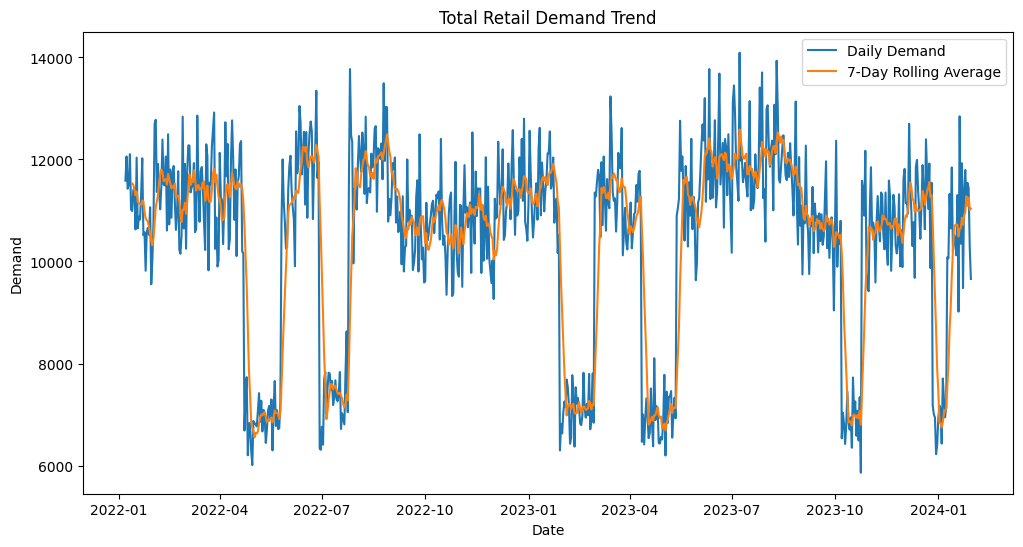

In [197]:
# Show Total Retail Demand Trend
plt.figure(figsize=(12,6))

plt.plot(
    daily_total["Date"],
    daily_total["Demand"],
    label="Daily Demand"
)

plt.plot(
    daily_total["Date"],
    daily_total["rolling_7d"],
    label="7-Day Rolling Average"
)

plt.legend()

plt.title("Total Retail Demand Trend")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

Forecasting

In [198]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor

In [199]:
# Model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [200]:
# Define target variable
y = df["Demand"]

In [201]:
# These variables may influence retail demand
features = [
    "Store_ID",
    "Product_ID",
    "Price",
    "Discount",
    "Competitor_Pricing",
    "Month_Num",
    "Day_Of_Week",
    "Promotion",
    "Category",
    "Region",
    "Weather_Condition",
    "Seasonality",
    "Epidemic",
    "rolling_7d_demand"
]

In [202]:
# Create feature dataset
X = df[features]

In [203]:
# Machine learning models cannot process text directly
# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)

In [204]:
# Time-based split
cutoff_date = df["Date"].quantile(0.8)
print("Training on data up to:", cutoff_date.date())
print("Testing on data after: ", df[df["Date"] > cutoff_date]["Date"].min().date())

train_mask = df["Date"] <= cutoff_date

X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train size: {len(X_train):,} rows")
print(f"Test size:  {len(X_test):,} rows")

Training on data up to: 2023-09-02
Testing on data after:  2023-09-03
Train size: 60,400 rows
Test size:  15,000 rows


In [205]:
# Build Random Forest Model
# Multiple decision trees work together to improve predictions
rf_model = RandomForestRegressor(
    n_estimators=100, # Number of trees
    random_state=42
)

In [206]:
# Train model on retail data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [207]:
# Predict demand for the test dataset
y_pred = rf_model.predict(X_test)

In [208]:
# Calculate Mean Absolute Error (on average, how far off were predictions)
mae = mean_absolute_error(y_test, y_pred)

In [209]:
# Root Mean Squared Error (measures prediction error)
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

In [210]:
# R^2 measures how much demand behavior did the model successfully explain
r2 = r2_score(y_test, y_pred)

In [211]:
# Mean Absolute Percentage Error (Predictions were off by _% on averge)
mape = (
    abs((y_test - y_pred) / y_test)
).mean() * 100

In [212]:
# Print model evaluation metrics
print("Model Performance Metrics")
print("--------------------------------------------------")
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)
print("Mean Absolute Percentage Error:", mape)

Model Performance Metrics
--------------------------------------------------
Mean Absolute Error: 17.920476
Root Mean Squared Error: 24.601329503368987
R^2 Score: 0.6897294783893171
Mean Absolute Percentage Error: 26.017582563011977


Feature Importance Analysis

In [213]:
# Identify which variables most strongly influence demand
# Higher importance means it had more influence on demand forecasting
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [214]:
# Sort features from highest importance to lowest
importance = importance.sort_values(
    by = "Importance",
    ascending = False
)

In [216]:
# Show top 10 most important features
print("\nTop 10 Most Important Features")
print("----------------------------------------")
print(importance.head(10))


Top 10 Most Important Features
----------------------------------------
                    Feature  Importance
7         rolling_7d_demand    0.464685
0                     Price    0.116756
5                 Promotion    0.077546
2        Competitor_Pricing    0.069297
4               Day_Of_Week    0.023130
1                  Discount    0.021406
3                 Month_Num    0.021280
40  Weather_Condition_Sunny    0.019795
6                  Epidemic    0.012761
33       Category_Groceries    0.008467


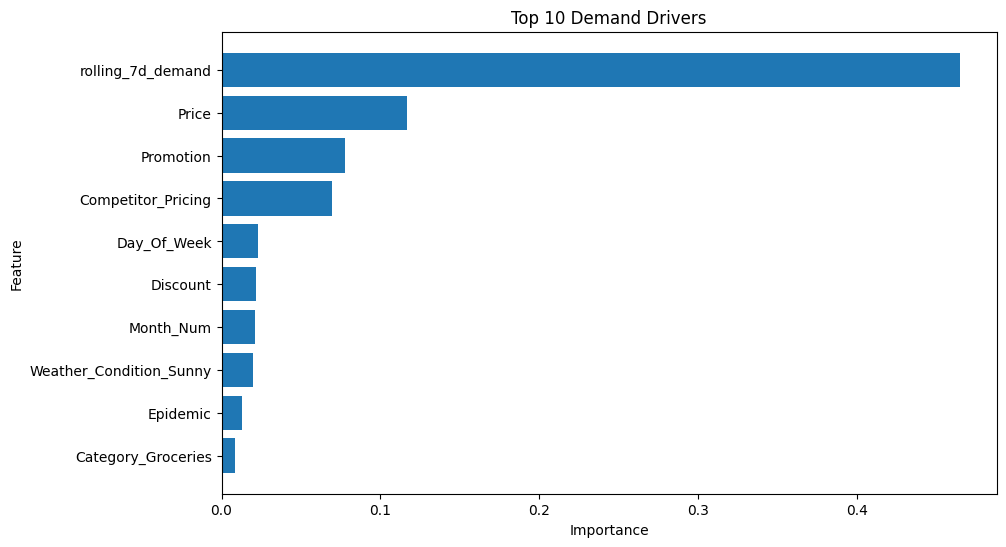

In [217]:
# Feature importance bar chart
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Demand Drivers")

plt.gca().invert_yaxis()

plt.show()

Actual vs Predicted Comparison

In [218]:
# Compare real demand values against model predictions
comparison = pd.DataFrame({
    "Actual_Demand": y_test,
    "Predicted_Demand": y_pred
})

In [219]:
print("\nActual vs Predicted Demand")
print("---------------------------------------")
print(comparison.head())


Actual vs Predicted Demand
---------------------------------------
       Actual_Demand  Predicted_Demand
61000             93            101.14
61100            111             95.79
61200            105            118.21
61300            115            107.56
61400            103             95.53


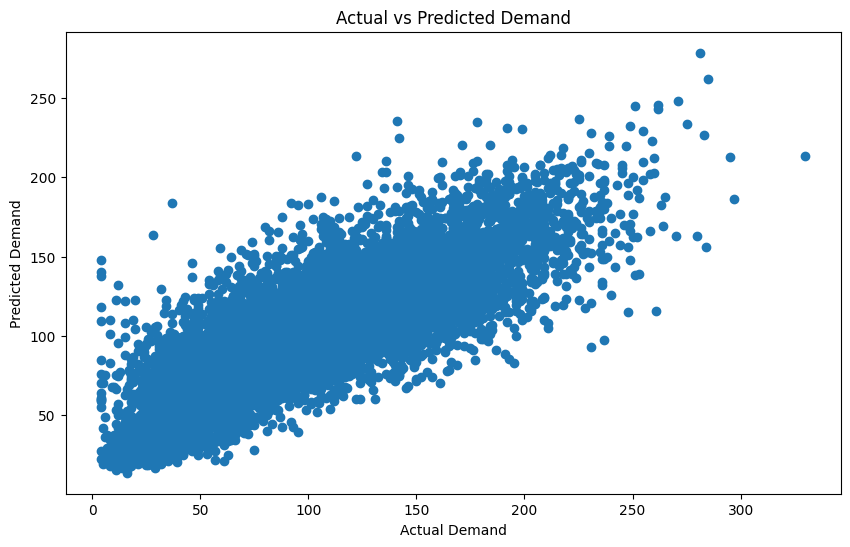

In [220]:
# Visualize model performance
# Using scatter plot to compare actual demand vs predicted demand
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.show()

In [225]:
# 30 Day Forecast (after dataset ends)
last_date = df["Date"].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

future_rows = []
for cat in df["Category"].unique():
    cat_df = df[df["Category"] == cat]
    for date in future_dates:
        row = {
            "Date": date,
            "Store_ID": cat_df["Store_ID"].mode()[0],
            "Product_ID": cat_df["Product_ID"].mode()[0],
            "Price": cat_df["Price"].mean(),
            "Discount": cat_df["Discount"].mean(),
            "Competitor_Pricing": cat_df["Competitor_Pricing"].mean(),
            "Month_Num": date.month,
            "Day_Of_Week": date.dayofweek + 1,
            "Promotion": 0,
            "Category": cat,
            "Region": cat_df["Region"].mode()[0],
            "Weather_Condition": cat_df["Weather_Condition"].mode()[0],
            "Seasonality": "Autumn",
            "Epidemic": 0,
            "rolling_7d_demand": cat_df["rolling_7d_demand"].iloc[-7:].mean()
        }
        future_rows.append(row)

future_df = pd.DataFrame(future_rows)

X_future = pd.get_dummies(future_df[features], drop_first=True)
X_future = X_future.reindex(columns=X_train.columns, fill_value=0)

future_df["Predicted_Demand"] = rf_model.predict(X_future)

print("30-Day Forecast: Average Daily Demand by Category")
print(future_df.groupby("Category")["Predicted_Demand"].mean().round(1))

30-Day Forecast: Average Daily Demand by Category
Category
Clothing       138.8
Electronics     87.7
Furniture       78.2
Groceries       89.7
Toys           106.7
Name: Predicted_Demand, dtype: float64


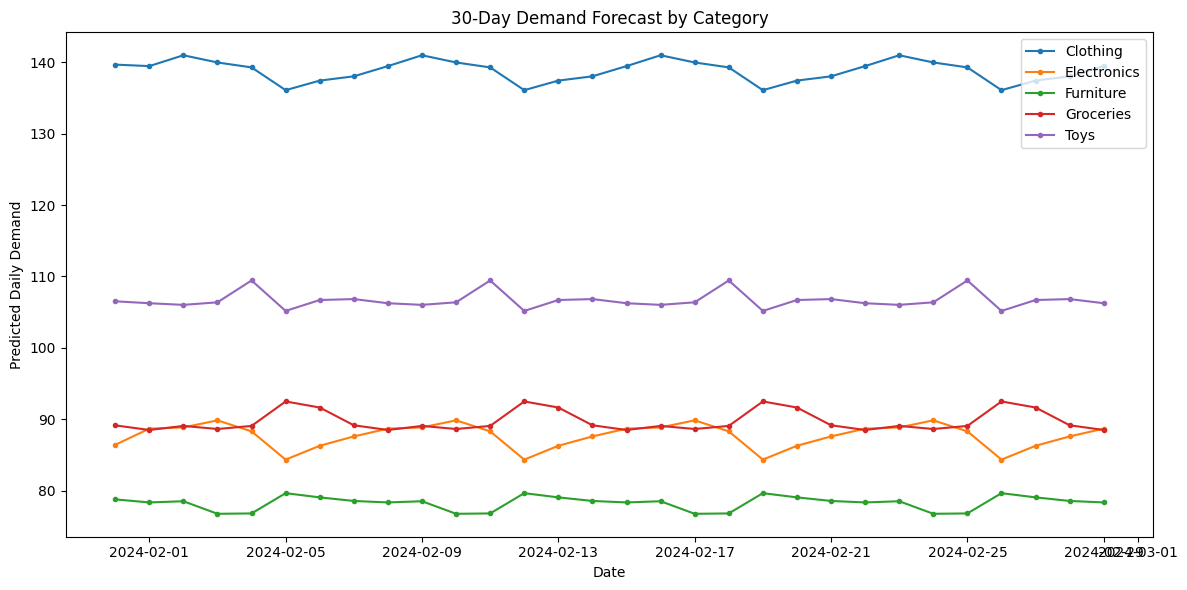

In [233]:
# Show 30 Day Demand Forecast by Category
plt.figure(figsize=(12, 6))

for cat in sorted(future_df["Category"].unique()):
    cat_data = future_df[future_df["Category"] == cat]
    plt.plot(cat_data["Date"], cat_data["Predicted_Demand"], label=cat, marker="o", markersize=3)

plt.title("30-Day Demand Forecast by Category")
plt.xlabel("Date")
plt.ylabel("Predicted Daily Demand")
plt.legend()
plt.tight_layout()
plt.show()

In [234]:
# Inventory risk classification table
# Calculate average daily demand per store/product
demand_avg = df.groupby(["Store_ID", "Product_ID"])["Demand"].mean().reset_index()
demand_avg.columns = ["Store_ID", "Product_ID", "avg_daily_demand"]

# Get the most recent inventory level per store/product
inventory_latest = df.sort_values("Date").groupby(["Store_ID", "Product_ID"]).last().reset_index()

# Combine into one table
risk = inventory_latest[["Store_ID", "Product_ID", "Category", "Region", "Inventory_Level"]].copy()
risk = risk.merge(demand_avg, on=["Store_ID", "Product_ID"])

# Calculate reorder point and weeks of supply
# Assumption: 7-day supplier lead time
risk["reorder_point"] = (risk["avg_daily_demand"] * 7).round(1)
risk["weeks_of_supply"] = (risk["Inventory_Level"] / risk["reorder_point"]).round(2)

# Classify each store/product
def classify_risk(row):
    if row["Inventory_Level"] == 0:
        return "Critical Stockout"
    elif row["Inventory_Level"] < row["reorder_point"] and row["weeks_of_supply"] < 0.5:
        return "Critical Stockout Risk"
    elif row["Inventory_Level"] < row["reorder_point"]:
        return "At Risk"
    elif row["Inventory_Level"] > row["avg_daily_demand"] * 14:
        return "Overstocked"
    else:
        return "Healthy"

risk["risk_classification"] = risk.apply(classify_risk, axis=1)

# Print results
print("Risk Classification Distribution:")
print(risk["risk_classification"].value_counts())
print()
print(risk.to_string(index=False))

Risk Classification Distribution:
risk_classification
Critical Stockout Risk    69
At Risk                   25
Healthy                    6
Name: count, dtype: int64

Store_ID Product_ID    Category Region  Inventory_Level  avg_daily_demand  reorder_point  weeks_of_supply    risk_classification
    S001      P0001 Electronics  North              383         92.685676          648.8             0.59                At Risk
    S001      P0002    Clothing  North              136        124.493369          871.5             0.16 Critical Stockout Risk
    S001      P0003    Clothing  North              434        123.277188          862.9             0.50                At Risk
    S001      P0004 Electronics  North              241         93.306366          653.1             0.37 Critical Stockout Risk
    S001      P0005   Groceries  North              946        120.381963          842.7             1.12                Healthy
    S001      P0006        Toys  North              436   

In [235]:
# Export CSVs for PowerBI
# Risk table
risk.to_csv("risk_table.csv", index=False)
print("Saved: risk_table.csv")

# 30-day forecast
future_df[["Date", "Category", "Predicted_Demand"]].to_csv("forecast_30day.csv", index=False)
print("Saved: forecast_30day.csv")

# Actual vs Predicted on test set
df_test = df[~train_mask].copy()
df_test["Predicted_Demand"] = y_pred
df_test[["Date", "Category", "Demand", "Predicted_Demand"]].to_csv("actuals_vs_predicted.csv", index=False)
print("Saved: actuals_vs_predicted.csv")

# Model metrics
pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "MAPE"],
    "Value":  [round(mae, 2), round(rmse, 2), round(r2, 4), round(mape, 2)]
}).to_csv("model_metrics.csv", index=False)
print("Saved: model_metrics.csv")

Saved: risk_table.csv
Saved: forecast_30day.csv
Saved: actuals_vs_predicted.csv
Saved: model_metrics.csv
